Dataset shape: (30, 8)

Columns:
Index(['Date', 'Max Temp (C)', 'Min Temp (C)', 'Humidity (%)', 'Rainfall (mm)',
       'Wind Speed (km/h)', 'Groundwater Level (m bgl)', 'Location'],
      dtype='str')

Cleaned dataset:
        Date  Max Temp (C)  Min Temp (C)  Humidity (%)  Rainfall (mm)  \
0 2026-07-19          31.3          22.8            74            0.1   
1 2026-07-20          32.1          23.1            68            0.1   
2 2026-07-21          30.5          22.4            81            4.5   
3 2026-07-22          29.8          22.1            86           14.2   
4 2026-07-23          30.2          22.5            79            2.4   

   Wind Speed (km/h)  Groundwater Level (m bgl)       Location  
0               12.5                       6.45  Coimbatore TN  
1               11.2                       6.48  Coimbatore TN  
2               15.0                       6.40  Coimbatore TN  
3               16.8                       6.22  Coimbatore TN  
4               

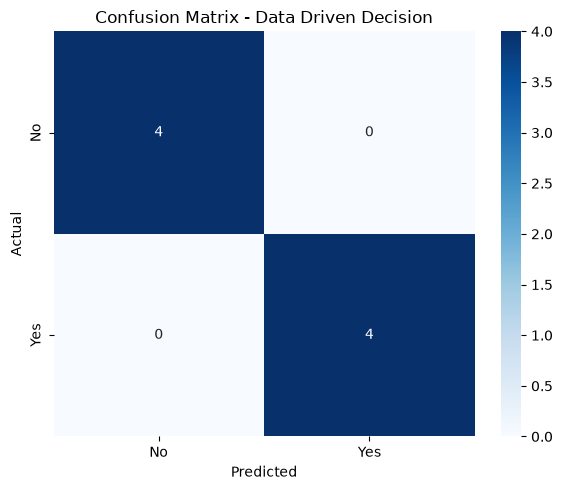

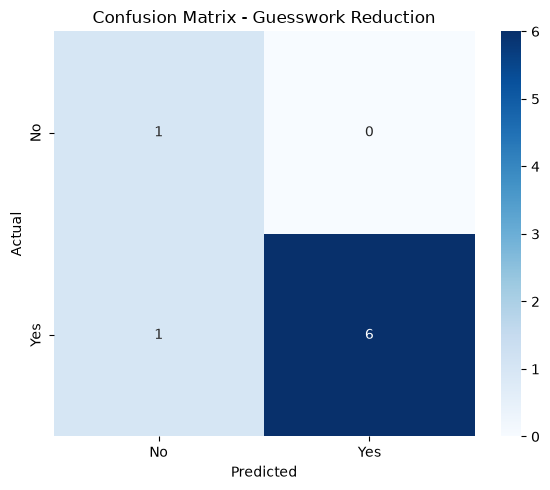

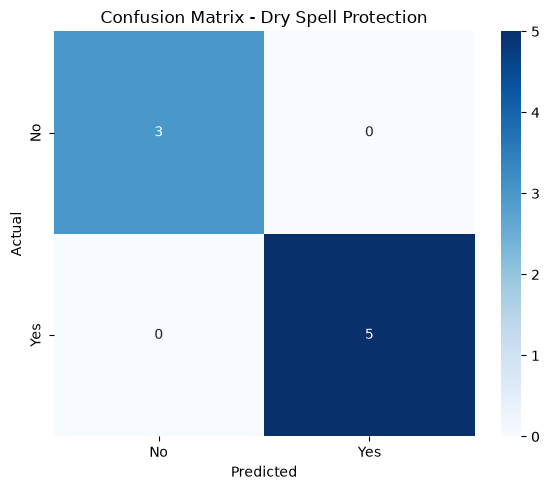

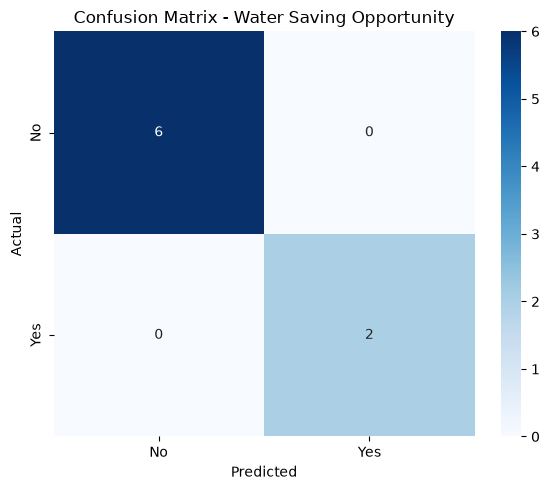

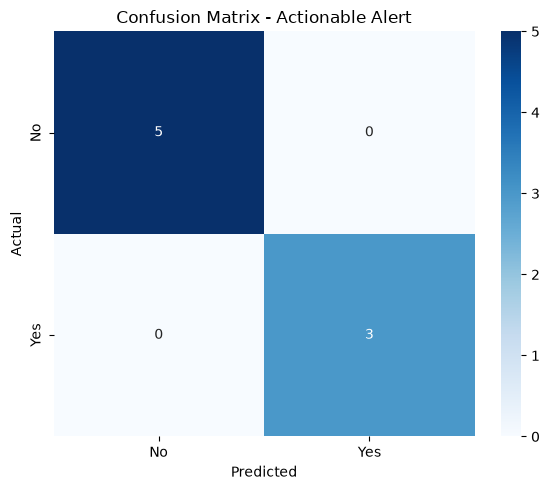

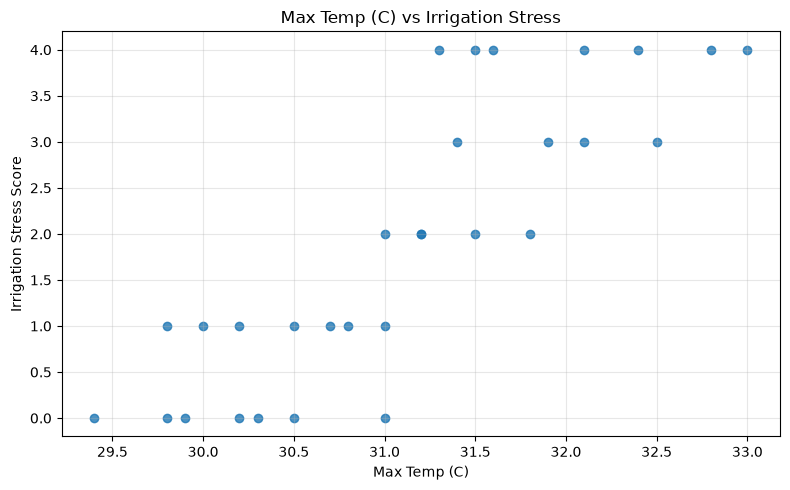

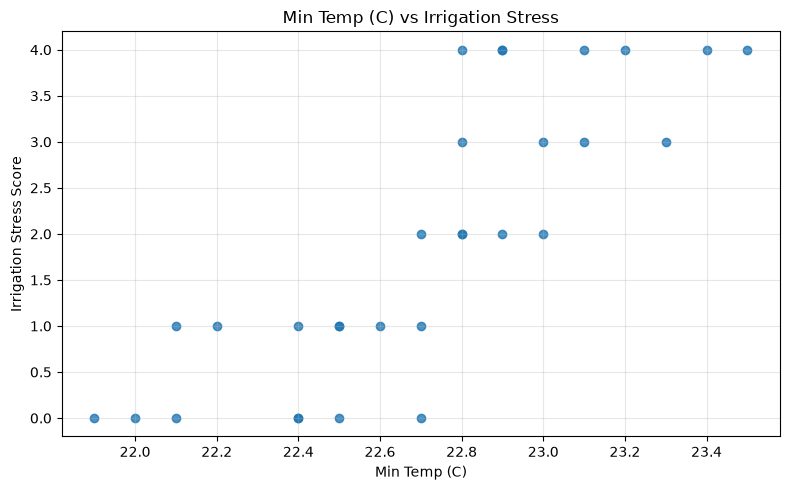

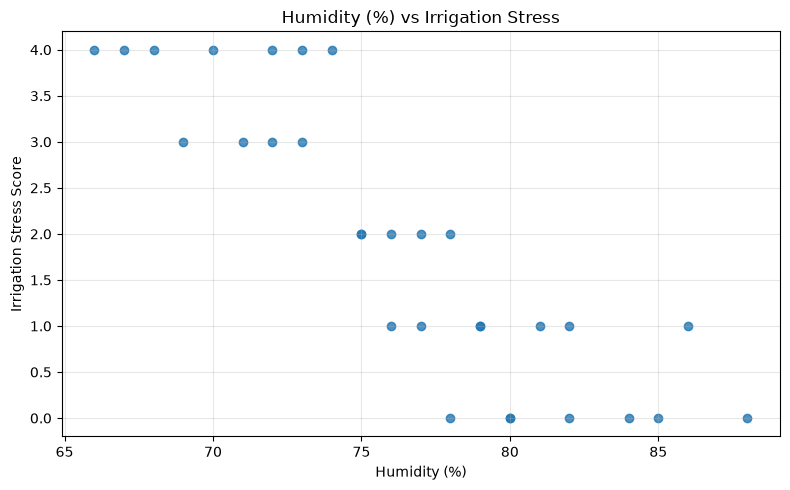

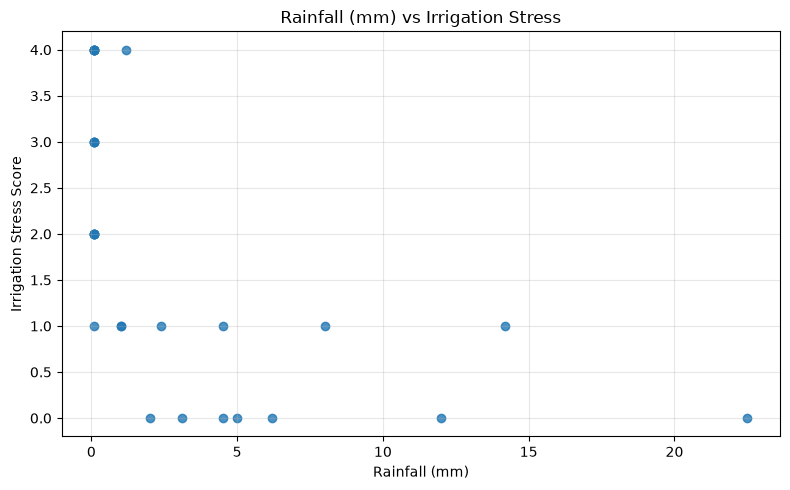

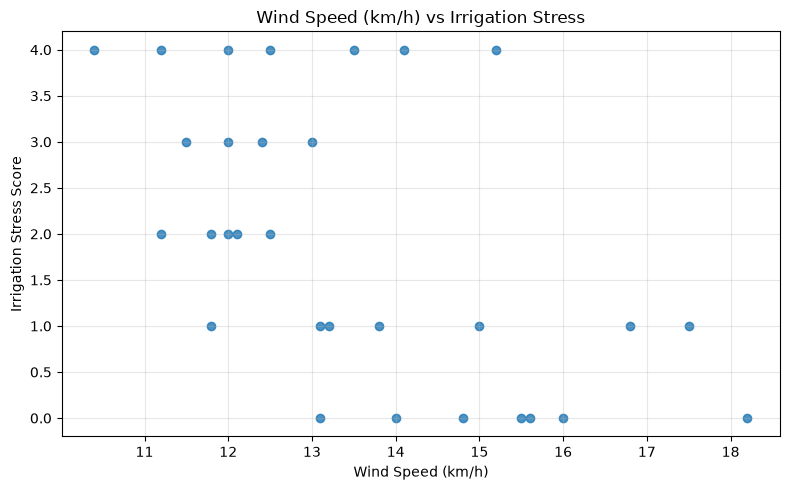

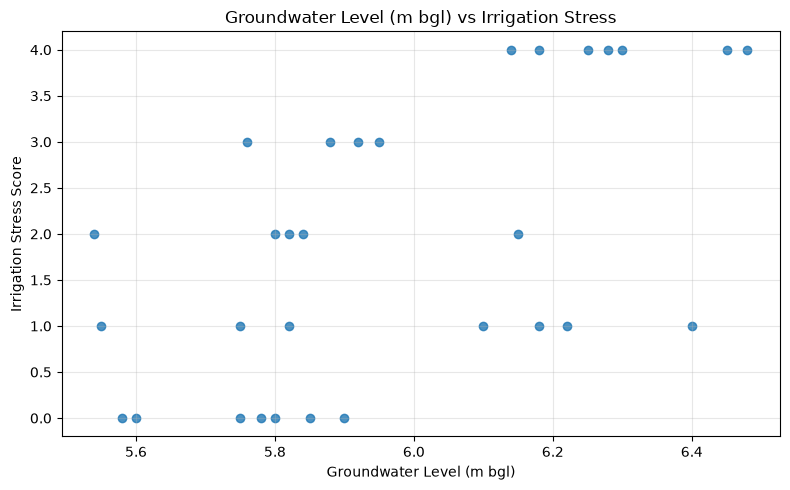

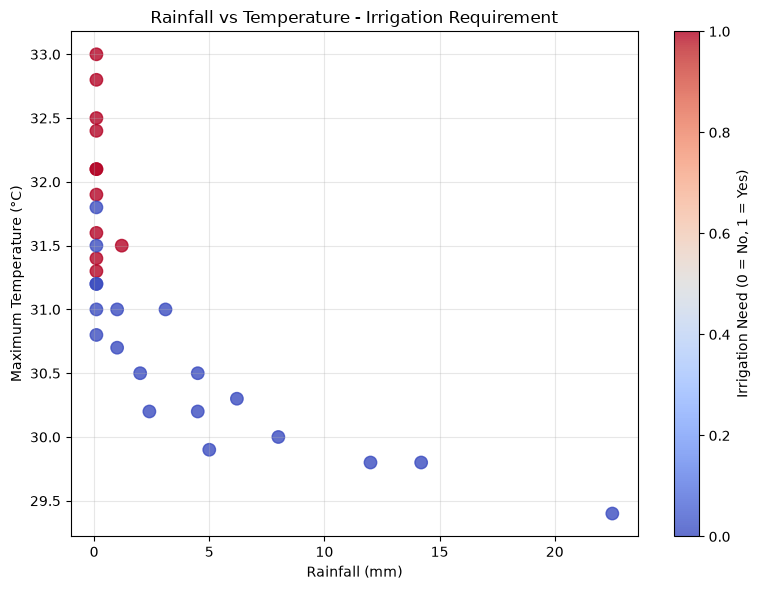

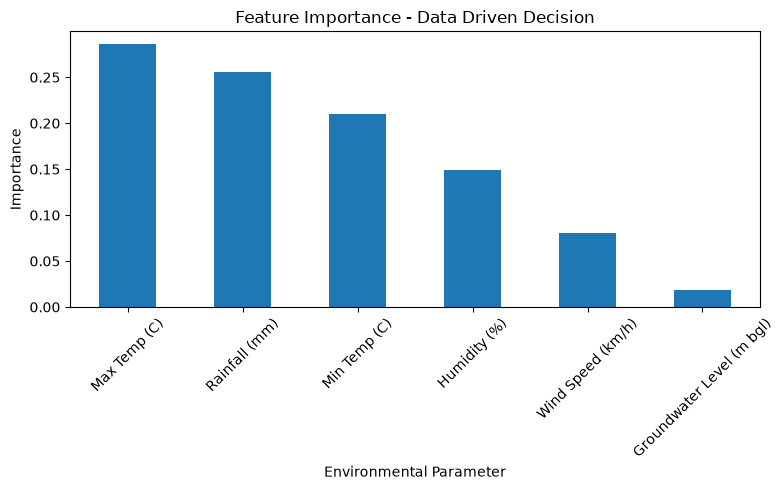

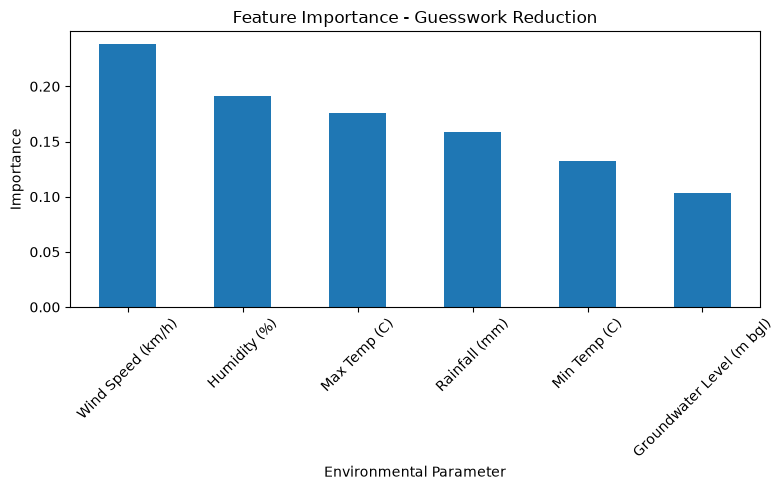

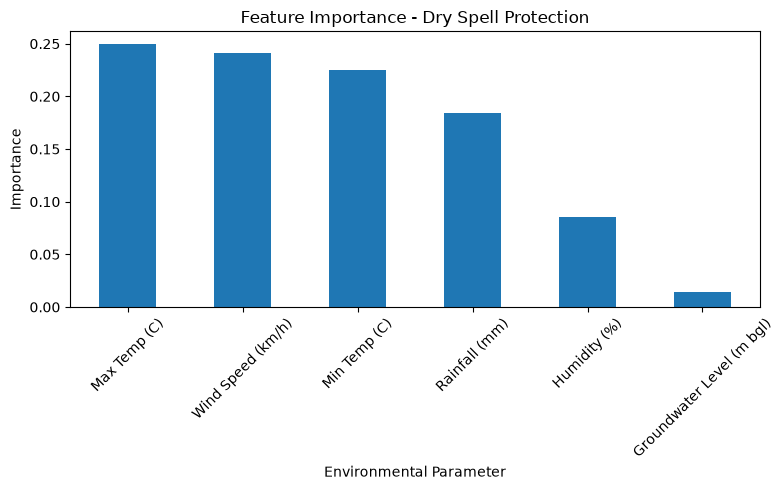

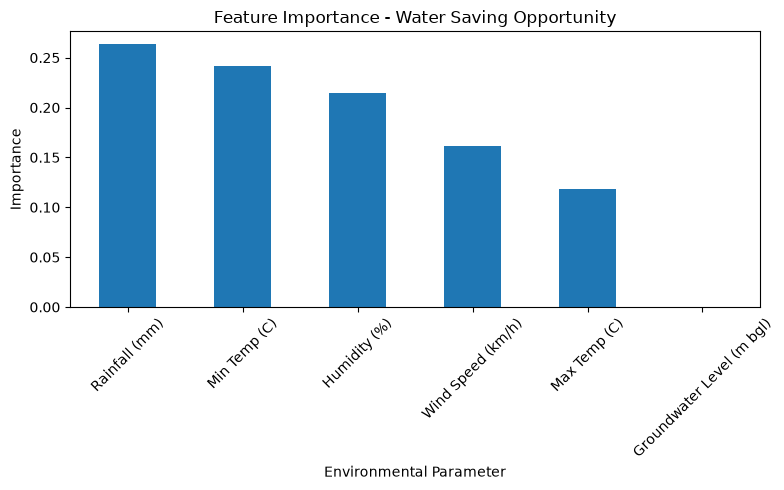

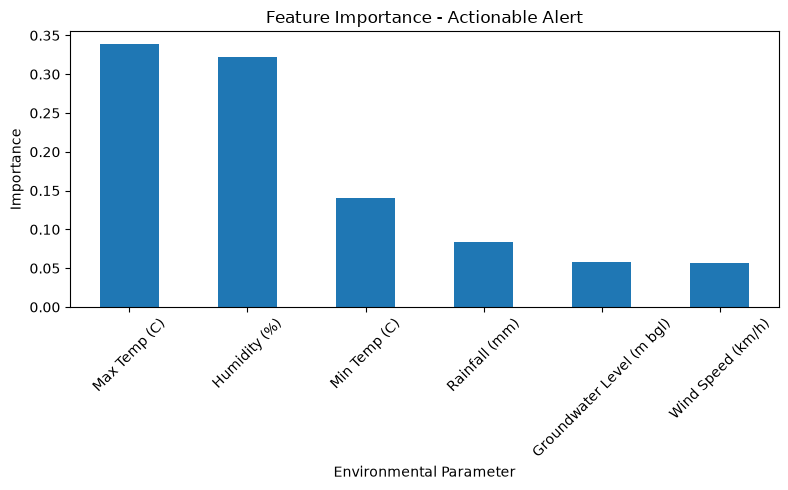

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


file_path = "coimbator.csv"

with open(file_path, "r", encoding="utf-8") as f:
    lines = f.readlines()

header_index = None

for i, line in enumerate(lines):
    if line.startswith("Date,Max Temp"):
        header_index = i
        break

data_lines = lines[header_index:]

clean_lines = []

for line in data_lines:
    line = line.strip()

    if line == "},,,,,,,":
        continue

    line = line.rstrip("\\")
    clean_lines.append(line)

from io import StringIO

data = pd.read_csv(StringIO("\n".join(clean_lines)))

print("Dataset shape:", data.shape)
print("\nColumns:")
print(data.columns)


data["Date"] = pd.to_datetime(
    data["Date"],
    format="%d-%m-%Y"
)

numeric_columns = [
    "Max Temp (C)",
    "Min Temp (C)",
    "Humidity (%)",
    "Rainfall (mm)",
    "Wind Speed (km/h)",
    "Groundwater Level (m bgl)"
]

for col in numeric_columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data = data.dropna()

print("\nCleaned dataset:")
print(data.head())

data["Stress Score"] = (
    (data["Max Temp (C)"] > 31).astype(int)
    + (data["Humidity (%)"] < 75).astype(int)
    + (data["Rainfall (mm)"] < 2).astype(int)
    + (data["Groundwater Level (m bgl)"] > 6).astype(int)
)

data["Irrigation Need"] = (
    data["Stress Score"] >= 3
).astype(int)

data["Data Driven Decision"] = (
    data["Stress Score"] >= 2
).astype(int)

data["Guesswork Reduction"] = (
    (data["Stress Score"] >= 3) |
    (data["Stress Score"] <= 1)
).astype(int)

data["Dry Spell Protection"] = (
    (data["Rainfall (mm)"] < 2) &
    (data["Max Temp (C)"] >= 31)
).astype(int)

data["Water Saving Opportunity"] = (
    data["Rainfall (mm)"] >= 4
).astype(int)

data["Actionable Alert"] = (
    data["Stress Score"] >= 3
).astype(int)


features = [
    "Max Temp (C)",
    "Min Temp (C)",
    "Humidity (%)",
    "Rainfall (mm)",
    "Wind Speed (km/h)",
    "Groundwater Level (m bgl)"
]

X = data[features]

targets = [
    "Data Driven Decision",
    "Guesswork Reduction",
    "Dry Spell Protection",
    "Water Saving Opportunity",
    "Actionable Alert"
]


models = {}
results = {}

for target in targets:

    y = data[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42,
        class_weight="balanced"
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    models[target] = model

    results[target] = {
        "y_test": y_test,
        "y_pred": y_pred,
        "accuracy": accuracy
    }

    print("\n")
    print(target)
    print("/n")
    print("Accuracy:", round(accuracy * 100, 2), "%")

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )


for target in targets:

    y_test = results[target]["y_test"]
    y_pred = results[target]["y_pred"]

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No", "Yes"],
        yticklabels=["No", "Yes"]
    )

    plt.title(
        "Confusion Matrix - " + target
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()


for feature in features:

    plt.figure(figsize=(8, 5))

    plt.scatter(
        data[feature],
        data["Stress Score"],
        alpha=0.8
    )

    plt.xlabel(feature)
    plt.ylabel("Irrigation Stress Score")

    plt.title(
        feature + " vs Irrigation Stress"
    )

    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    data["Rainfall (mm)"],
    data["Max Temp (C)"],
    c=data["Irrigation Need"],
    cmap="coolwarm",
    s=80,
    alpha=0.8
)

plt.xlabel("Rainfall (mm)")
plt.ylabel("Maximum Temperature (°C)")

plt.title(
    "Rainfall vs Temperature - Irrigation Requirement"
)

plt.colorbar(
    scatter,
    label="Irrigation Need (0 = No, 1 = Yes)"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


for target in targets:

    model = models[target]

    importance = pd.Series(
        model.feature_importances_,
        index=features
    ).sort_values(ascending=False)

    plt.figure(figsize=(8, 5))

    importance.plot(
        kind="bar"
    )

    plt.title(
        "Feature Importance - " + target
    )

    plt.xlabel("Environmental Parameter")
    plt.ylabel("Importance")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()